2026-02-01 13:44:56.159261: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1769953496.654824      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1769953496.801171      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1769953498.042400      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769953498.042459      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769953498.042462      23 computation_placer.cc:177] computation placer alr

 1. Scanning directory for image paths …
   Found 38 classes.
   Indexed 54305 images (paths only, no pixels loaded).

 2. Splitting indices …
   Training pool: 46159 image paths
   Global test  : 8146 image paths

 3. Partitioning into client shards …
   Client 0: 15397 image paths
   Client 1: 15387 image paths
   Client 2: 15375 image paths

 4. Starting Federated Learning …


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1769953526.452347      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1769953526.458839      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5



--- Federated Round 1/10 ---


I0000 00:00:1769953531.741573      66 service.cc:152] XLA service 0x7a5df4005f40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1769953531.741626      66 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1769953531.741632      66 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1769953532.234310      66 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-02-01 13:45:34.767520: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-01 13:45:34.914894: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1769953536.988857      66 device_co

      Client 0 trained on 15397 samples for 2 epoch(s).


2026-02-01 13:46:50.495200: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-01 13:46:50.642395: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


      Client 1 trained on 15387 samples for 2 epoch(s).
      Client 2 trained on 15375 samples for 2 epoch(s).
   Server aggregated weights (FedAvg).
   Global test accuracy after round 1: 0.5346  (53.46 %)

--- Federated Round 2/10 ---
      Client 0 trained on 15397 samples for 2 epoch(s).
      Client 1 trained on 15387 samples for 2 epoch(s).
      Client 2 trained on 15375 samples for 2 epoch(s).
   Server aggregated weights (FedAvg).
   Global test accuracy after round 2: 0.8922  (89.22 %)

--- Federated Round 3/10 ---
      Client 0 trained on 15397 samples for 2 epoch(s).
      Client 1 trained on 15387 samples for 2 epoch(s).
      Client 2 trained on 15375 samples for 2 epoch(s).
   Server aggregated weights (FedAvg).
   Global test accuracy after round 3: 0.9331  (93.31 %)

--- Federated Round 4/10 ---
      Client 0 trained on 15397 samples for 2 epoch(s).
      Client 1 trained on 15387 samples for 2 epoch(s).
      Client 2 trained on 15375 samples for 2 epoch(s).
   Ser

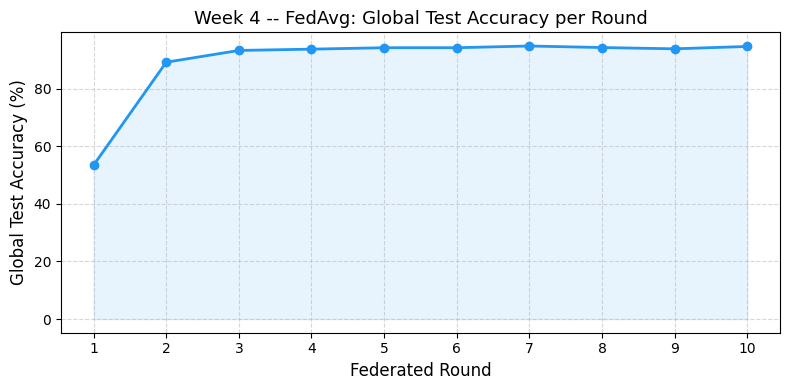


  Saved round_accuracy -> week4_round_accuracy.json
  (ready for Week 5 comparison / plotting)


In [1]:
import os, gc, json
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# HYPER-PARAMETERS  (tweak here only)
# ---------------------------------------------------------
DATA_DIR        = "/kaggle/input/plantvillage-dataset/color"
IMG_SIZE        = (128, 128)          # reduced from 224 to fit in RAM
NUM_CLIENTS     = 3
FED_ROUNDS      = 10
LOCAL_EPOCHS    = 2                   # epochs each client trains per round
LOCAL_BATCH     = 32
LEARNING_RATE   = 1e-3
TEST_SPLIT      = 0.15                # fraction held out as global test set
SEED            = 42

tf.random.set_seed(SEED)
np.random.seed(SEED)

# ---------------------------------------------------------
# 1.  COLLECT FILE PATHS + LABELS  (no pixel data yet)
# ---------------------------------------------------------
print("=" * 60)
print(" 1. Scanning directory for image paths …")
print("=" * 60)

# sorted class list -> deterministic label mapping (same as Week 3)
class_names = sorted(
    d for d in os.listdir(DATA_DIR)
    if os.path.isdir(os.path.join(DATA_DIR, d))
)
NUM_CLASSES  = len(class_names)
class_to_idx = {name: i for i, name in enumerate(class_names)}
print(f"   Found {NUM_CLASSES} classes.")

# Build lightweight index: list of (filepath, int_label)
all_paths  = []   # str
all_labels = []   # int

for cls_name, cls_idx in class_to_idx.items():
    cls_dir = os.path.join(DATA_DIR, cls_name)
    for fname in os.listdir(cls_dir):
        if fname.lower().endswith((".jpg", ".jpeg", ".png")):
            all_paths.append(os.path.join(cls_dir, fname))
            all_labels.append(cls_idx)

all_paths  = np.array(all_paths)          # numpy array of strings
all_labels = np.array(all_labels, dtype=np.int32)
print(f"   Indexed {len(all_paths)} images (paths only, no pixels loaded).")

# ---------------------------------------------------------
# 2.  SPLIT INDICES: global-test  |  training pool
#     We shuffle and split only the INDEX arrays -- zero pixel cost.
# ---------------------------------------------------------
print("\n" + "=" * 60)
print(" 2. Splitting indices …")
print("=" * 60)

from sklearn.model_selection import train_test_split

indices = np.arange(len(all_paths))
train_idx, test_idx = train_test_split(
    indices,
    test_size=TEST_SPLIT,
    stratify=all_labels,          # class-balanced split
    random_state=SEED
)

# Separate path/label arrays for test set
test_paths  = all_paths[test_idx]
test_labels = all_labels[test_idx]

# Training pool paths & labels
train_paths  = all_paths[train_idx]
train_labels = all_labels[train_idx]

# Free the full arrays -- we no longer need them
del all_paths, all_labels, indices, train_idx, test_idx
gc.collect()

print(f"   Training pool: {len(train_paths)} image paths")
print(f"   Global test  : {len(test_paths)} image paths")

# ---------------------------------------------------------
# 3.  PARTITION training pool into NUM_CLIENTS DISJOINT shards
#     Still index-only -- each client gets a (paths, labels) pair.
# ---------------------------------------------------------
print("\n" + "=" * 60)
print(" 3. Partitioning into client shards …")
print("=" * 60)

def stratified_partition_paths(paths, labels, n_clients, seed):
    """
    Partition (paths, labels) into n_clients disjoint subsets,
    stratified by class so every client sees every class.
    Returns list of (paths_array, labels_array) -- no pixels.
    """
    rng = np.random.RandomState(seed)
    n_classes = labels.max() + 1

    # Per-client bucket lists (of indices into paths/labels)
    client_indices = [[] for _ in range(n_clients)]

    for c in range(n_classes):
        idx_c = np.where(labels == c)[0]
        idx_c = rng.permutation(idx_c)              # shuffle within class
        # round-robin split into n_clients chunks
        splits = np.array_split(idx_c, n_clients)
        for k, chunk in enumerate(splits):
            client_indices[k].extend(chunk.tolist())

    # Build per-client arrays and shuffle
    client_datasets = []
    for k in range(n_clients):
        idx_k = np.array(client_indices[k])
        idx_k = rng.permutation(idx_k)              # shuffle
        p_k   = paths[idx_k]
        l_k   = labels[idx_k]
        client_datasets.append((p_k, l_k))
        print(f"   Client {k}: {len(p_k)} image paths")

    return client_datasets

client_datasets = stratified_partition_paths(
    train_paths, train_labels, NUM_CLIENTS, SEED
)

# Free the full training pool arrays
del train_paths, train_labels
gc.collect()

# ---------------------------------------------------------
# 4.  tf.data PIPELINE  (loads pixels on-the-fly, batch by batch)
# ---------------------------------------------------------

def _load_and_preprocess(path, label):
    """
    TensorFlow graph-mode function: reads one JPEG from disk,
    resizes to IMG_SIZE, and normalises to [0, 1].
    This runs inside the tf.data pipeline -- only one batch of
    images is ever resident in memory at a time.
    """
    raw   = tf.io.read_file(path)
    image = tf.io.decode_jpeg(raw, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = image / 255.0                          # normalise
    label = tf.one_hot(label, NUM_CLASSES)         # one-hot encode
    return image, label


def make_dataset(paths, labels, batch_size, shuffle_data=True):
    """
    Build a tf.data.Dataset from path/label arrays.
    Images are loaded lazily -- only `batch_size` images in RAM at once.
    """
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle_data:
        ds = ds.shuffle(buffer_size=1024, seed=SEED)
    ds = ds.map(_load_and_preprocess,
                num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

# ---------------------------------------------------------
# 5.  MODEL FACTORY  (same CNN as Week 3, input size updated)
# ---------------------------------------------------------
def build_model():
    """
    Exact same CNN topology as Week 3:
      Conv(32)->Pool -> Conv(64)->Pool -> Conv(128)->Pool ->
      Flatten -> Dense(128, relu) -> Dense(NUM_CLASSES, softmax)

    Only IMG_SIZE changed (128x128 instead of 224x224).
    """
    model = keras.Sequential([
        layers.Conv2D(32, 3, activation="relu",
                      input_shape=(*IMG_SIZE, 3)),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, activation="relu"),
        layers.MaxPooling2D(),
        layers.Conv2D(128, 3, activation="relu"),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dense(NUM_CLASSES, activation="softmax")
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(LEARNING_RATE),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

# ---------------------------------------------------------
# 6.  CLIENT LOGIC
# ---------------------------------------------------------
def client_train(client_id, global_weights, client_data):
    """
    Simulate one client's local training step.

    Steps:
      a) Build a fresh model (same architecture as server).
      b) Load the global weights the server broadcast.
      c) Create a tf.data pipeline for THIS client's shard
         (images load from disk batch-by-batch -- no big array).
      d) Train for LOCAL_EPOCHS.
      e) Return updated weights + number of local samples.

    Parameters
    ----------
    client_id      : int
    global_weights : list of np arrays  (from server)
    client_data    : (paths_array, labels_array)

    Returns
    -------
    updated_weights : list of np arrays
    n_samples       : int
    """
    paths, labels = client_data
    n_samples = len(paths)

    # --- (a) & (b) ---
    local_model = build_model()
    local_model.set_weights(global_weights)

    # --- (c) on-the-fly dataset ---
    train_ds = make_dataset(paths, labels, batch_size=LOCAL_BATCH,
                            shuffle_data=True)

    # --- (d) train ---
    local_model.fit(train_ds, epochs=LOCAL_EPOCHS, verbose=0)

    print(f"      Client {client_id} trained on {n_samples} samples "
          f"for {LOCAL_EPOCHS} epoch(s).")

    # --- (e) extract weights, then destroy model to free GPU mem ---
    updated_weights = local_model.get_weights()
    del local_model, train_ds
    gc.collect()
    tf.keras.backend.clear_session()
    return updated_weights, n_samples

# ---------------------------------------------------------
# 7.  SERVER AGGREGATION  (FedAvg -- weighted average)
# ---------------------------------------------------------
def fedavg_aggregate(client_weights_list):
    """
    Federated Averaging (McMahan et al., 2017).

    Input: list of (weights, n_samples) from each client.
    Output: aggregated weights list.

    Formula per layer l:
        w_global[l] = sum_k  (n_k / N_total) * w_k[l]

    Clients with more data contribute proportionally more.
    """
    total_samples = sum(n for _, n in client_weights_list)
    n_layers      = len(client_weights_list[0][0])

    # initialise accumulators to zero
    aggregated = [
        np.zeros_like(client_weights_list[0][0][l])
        for l in range(n_layers)
    ]

    for weights, n_samples in client_weights_list:
        factor = n_samples / total_samples
        for l in range(n_layers):
            aggregated[l] += factor * weights[l]

    return aggregated

# ---------------------------------------------------------
# 8.  EVALUATION HELPER
# ---------------------------------------------------------
def evaluate_global_model(global_weights, test_paths, test_labels):
    """
    Evaluate on the held-out test set.
    Uses the same on-the-fly tf.data pipeline -- no big array.
    """
    eval_model = build_model()
    eval_model.set_weights(global_weights)

    test_ds = make_dataset(test_paths, test_labels,
                           batch_size=LOCAL_BATCH, shuffle_data=False)
    _, accuracy = eval_model.evaluate(test_ds, verbose=0)

    del eval_model, test_ds
    gc.collect()
    tf.keras.backend.clear_session()
    return accuracy

# ---------------------------------------------------------
# 9.  FEDERATED TRAINING LOOP
# ---------------------------------------------------------
print("\n" + "=" * 60)
print(" 4. Starting Federated Learning …")
print("=" * 60)

# --- initialise global model weights (random init) ---
init_model     = build_model()
global_weights = init_model.get_weights()
del init_model; gc.collect()

# --- per-round accuracy log (exported for Week 5) ---
round_accuracy = {}   # { round_number : test_accuracy }

for fed_round in range(1, FED_ROUNDS + 1):
    print(f"\n--- Federated Round {fed_round}/{FED_ROUNDS} ---")

    # -- (a) SERVER -> CLIENTS: broadcast global weights --
    #     (simulated: we just pass the variable)

    # -- (b) Each client trains locally --
    client_results = []
    for cid in range(NUM_CLIENTS):
        updated_w, n_samp = client_train(
            cid, global_weights, client_datasets[cid]
        )
        client_results.append((updated_w, n_samp))

    # -- (c) CLIENTS -> SERVER: already collected above --

    # -- (d) SERVER aggregates via FedAvg --
    global_weights = fedavg_aggregate(client_results)
    del client_results; gc.collect()
    print("   Server aggregated weights (FedAvg).")

    # -- (e) SERVER evaluates on held-out test set --
    acc = evaluate_global_model(global_weights, test_paths, test_labels)
    round_accuracy[fed_round] = float(acc)
    print(f"   Global test accuracy after round {fed_round}: "
          f"{acc:.4f}  ({acc * 100:.2f} %)")

# ---------------------------------------------------------
# 10. RESULTS  (print + plot + save)
# ---------------------------------------------------------
print("\n" + "=" * 60)
print(" 5. Federated Learning Complete")
print("=" * 60)
print("\n  Per-round global test accuracy:")
print("  " + "-" * 36)
for rnd, acc in round_accuracy.items():
    print(f"    Round {rnd:>2d}  ->  {acc * 100:6.2f} %")
print("  " + "-" * 36)

# --- Plot ---
rounds = list(round_accuracy.keys())
accs   = [round_accuracy[r] * 100 for r in rounds]

plt.figure(figsize=(8, 4))
plt.plot(rounds, accs, marker="o", linewidth=2, color="#2196F3")
plt.fill_between(rounds, accs, alpha=0.1, color="#2196F3")
plt.xlabel("Federated Round", fontsize=12)
plt.ylabel("Global Test Accuracy (%)", fontsize=12)
plt.title("Week 4 -- FedAvg: Global Test Accuracy per Round", fontsize=13)
plt.xticks(rounds)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# --- Save for Week 5 ---
with open("week4_round_accuracy.json", "w") as f:
    json.dump(round_accuracy, f, indent=2)
print("\n  Saved round_accuracy -> week4_round_accuracy.json")
print("  (ready for Week 5 comparison / plotting)")